# Humoto → SMPL-X / InterAct — visual inspection

All processing logic lives in `process/process_humoto.py`. This notebook only **loads** that module and **visualizes** results. Edit the `.py`; cells here pick up changes via `autoreload`.

Run order: imports → load models → process one sequence → overlay check → mesh+object render → video.

In [25]:
%load_ext autoreload
%autoreload 2

import os, numpy as np, torch, trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.spatial.transform import Rotation as Rot

from process.process_humoto import (
    process_humoto_sequence, load_models, load_targets, load_all_targets,
    BODY_CORR, PARENTS, BODY_NAMES, Z_TO_Y_MAT,
    HAND_CORR, HAND_SMPLX_IDX, HAND_NAMES,
    HUMOTO_UPBONE, HUMOTO_RAW, OUTPUT_ROOT,
)
print('imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
imports OK


In [26]:
# Build SMPL-X + Mixamo models once (reused by every cell below)
m, mx_model = load_models('./models')
print('models loaded')

models loaded


In [ ]:
# Choose the sequence to inspect
SEQ_NAME    = 'baking_with_spatula_mixing_bowl_and_scooping_to_tray-244'
PRIMARY_OBJ = 'spatula'
PKL_PATH    = os.path.join(HUMOTO_UPBONE, SEQ_NAME, f'{SEQ_NAME}.pkl')
GLB_PATH    = os.path.join(HUMOTO_RAW,    SEQ_NAME, f'{SEQ_NAME}.glb')

result = process_humoto_sequence(
    pkl_path=PKL_PATH, glb_path=GLB_PATH,
    seq_name=SEQ_NAME, primary_object=PRIMARY_OBJ,
    smplx_model=m, mx_model=mx_model, output_root=f'{OUTPUT_ROOT}', seed=0,
)
result

[1/4] baking_with_spatula_mixing_bowl_and_scooping_to_tray-244: T=293, objects=['mixing_bowl', 'spatula', 'table', 'tray']

=== Fitting sequence (T=293) ===


per-frame pose fit: 100%|██████████| 292/292 [04:30<00:00,  1.08it/s]

[2/4] fit: mean=2.98cm  max=3.09cm  ||beta||=0.86
[3/4] wrote human.npz + object.npz → ./data/humoto_temp/sequences_canonical/baking_with_spatula_mixing_bowl_and_scooping_to_tray-244
[4/4] wrote spatula mesh + sample_points → ./data/humoto_temp/objects/spatula


{'seq_dir': './data/humoto_temp/sequences_canonical/baking_with_spatula_mixing_bowl_and_scooping_to_tray-244',
 'obj_dir': './data/humoto_temp/objects/spatula',
 'betas': array([-0.8273615 ,  0.13182306, -0.13495483,  0.08120145,  0.03543864,
         0.07834297, -0.01715355, -0.00280334, -0.07384025, -0.00802231,
         0.04073953, -0.04474779, -0.0382368 ,  0.01456073,  0.00657634,
         0.0072595 ], dtype=float32),
 'mean_err_cm': 2.976578287780285,
 'max_err_cm': 3.0872892588377,
 'T': 293}

In [ ]:
# Load what we just wrote, so the plots below reflect the on-disk files
seq_dir = result['seq_dir']
obj_dir = result['obj_dir']
human   = np.load(os.path.join(seq_dir, 'human.npz'), allow_pickle=True)
objnpz  = np.load(os.path.join(seq_dir, f'object_{PRIMARY_OBJ}.npz'), allow_pickle=True)

poses = human['poses']                 # (T, 156)
betas = human['betas']                 # (16,)
trans = human['trans']                 # (T, 3)
T     = poses.shape[0]
betas_fit = torch.from_numpy(betas)[None].float()
fitted_go = poses[:, :3].astype(np.float32)
fitted_bp = poses[:, 3:66].astype(np.float32)
fitted_lh = poses[:, 66:111].astype(np.float32)    # left hand pose (45)
fitted_rh = poses[:, 111:156].astype(np.float32)   # right hand pose (45)
fitted_tr = trans.astype(np.float32)

obj_angles = objnpz['angles']          # (T, 3)
obj_trans  = objnpz['trans']           # (T, 3)
spatula_obj = trimesh.load(os.path.join(obj_dir, f'{PRIMARY_OBJ}.obj'))

# Mixamo joint targets (the fit's ground truth): body (22) + hands (40), one FK pass
all_targets, hand_targets, _ = load_all_targets(PKL_PATH, mx_model)   # (T,22,3), (T,40,3)
print(f'T={T}, betas norm={np.linalg.norm(betas):.2f}, mean_err={result["mean_err_cm"]:.2f}cm, '
      f'body_targets={all_targets.shape}, hand_targets={hand_targets.shape}')

T=293, betas norm=0.86, mean_err=2.98cm, all_targets=(293, 22, 3)


## 1. Marker silhouette (frame 0)
Run SMPL-X forward, confirm the body looks human and stands at a sensible height.

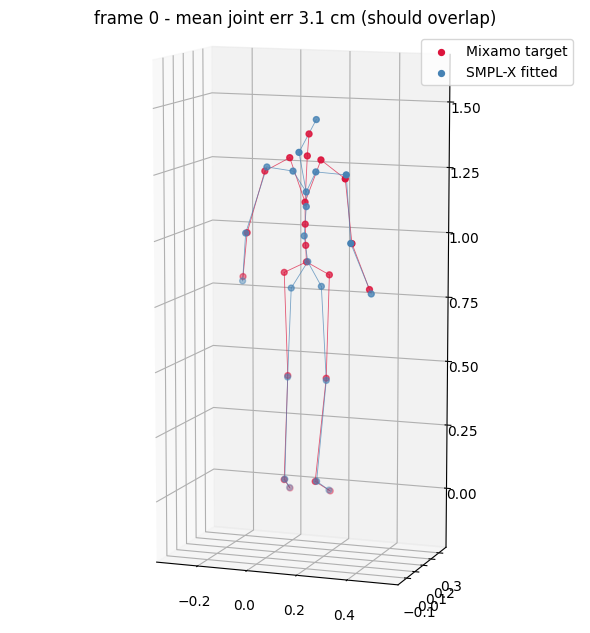

In [33]:
# HAND_CORR is grouped 4-per-finger (base, mid, distal, tip): 5 left fingers then
# 5 right. So within the 40-point hand array, each block of 4 is one finger chain.
FINGER_CHAINS   = [(b + i, b + i + 1) for b in range(0, 40, 4) for i in range(3)]
WRIST_OF_FINGER = {g: (20 if g < 5 else 21) for g in range(10)}  # body wrist per finger
HAND_SLICE      = {'left': slice(0, 20), 'right': slice(20, 40), None: slice(0, 40)}

def _skel(ax, J, edges, c, s=18, lw=0.6, label=None):
    for a, b in edges:
        ax.plot([J[a,0],J[b,0]], [J[a,2],J[b,2]], [J[a,1],J[b,1]], '-', color=c, lw=lw, alpha=0.7)
    ax.scatter(J[:,0], J[:,2], J[:,1], c=c, s=s, label=label)

def render_overlay(t, show_hands=True, focus=None, azim=-70, elev=10):
    """Mixamo target (crimson) vs fitted SMPL-X (blue): body + the 40 finger joints.
    focus=None -> full body; focus='left'/'right' -> zoom on that hand's grasp."""
    with torch.no_grad():
        J = m(global_orient  =torch.from_numpy(fitted_go[t:t+1]),
              body_pose      =torch.from_numpy(fitted_bp[t:t+1]),
              left_hand_pose =torch.from_numpy(fitted_lh[t:t+1]),
              right_hand_pose=torch.from_numpy(fitted_rh[t:t+1]),
              transl         =torch.from_numpy(fitted_tr[t:t+1]),
              betas          =betas_fit).joints[0]
    pred_b, pred_h = J[:22].numpy(), J[HAND_SMPLX_IDX].numpy()
    tgt_b,  tgt_h  = all_targets[t], hand_targets[t]
    berr = np.linalg.norm(pred_b - tgt_b, axis=1).mean() * 100

    # which fingers/groups to draw (only the focused hand, to avoid stray lines)
    sl = HAND_SLICE[focus]
    fingers = [g for g in range(10) if (focus is None
               or (focus == 'left' and g < 5) or (focus == 'right' and g >= 5))]
    chains  = [(a, b) for (a, b) in FINGER_CHAINS if a in range(sl.start, sl.stop)]
    herr = np.linalg.norm(pred_h[sl] - tgt_h[sl], axis=1).mean() * 100

    fig = plt.figure(figsize=(7, 8)); ax = fig.add_subplot(111, projection='3d')
    body_edges = [(p, k) for k, p in enumerate(PARENTS) if p >= 0]
    _skel(ax, tgt_b,  body_edges, 'crimson',   label='Mixamo target')
    _skel(ax, pred_b, body_edges, 'steelblue', label='SMPL-X fitted')
    if show_hands:
        for Jb, Jh, c in [(tgt_b, tgt_h, 'crimson'), (pred_b, pred_h, 'steelblue')]:
            for a, b in chains:
                ax.plot([Jh[a,0],Jh[b,0]], [Jh[a,2],Jh[b,2]], [Jh[a,1],Jh[b,1]], '-', color=c, lw=0.6, alpha=0.7)
            ax.scatter(Jh[sl,0], Jh[sl,2], Jh[sl,1], c=c, s=10)
            for g in fingers:                               # base of each finger -> its wrist
                base, wj = g * 4, WRIST_OF_FINGER[g]
                ax.plot([Jb[wj,0],Jh[base,0]], [Jb[wj,2],Jh[base,2]], [Jb[wj,1],Jh[base,1]],
                        '-', color=c, lw=0.5, alpha=0.5)

    if focus in ('left', 'right'):
        pts = np.vstack([tgt_h[sl], pred_h[sl]]); lo, hi = pts.min(0) - 0.03, pts.max(0) + 0.03
    else:
        pts = np.vstack([tgt_b, pred_b, tgt_h, pred_h]); lo, hi = pts.min(0) - 0.1, pts.max(0) + 0.1
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
    ax.set_box_aspect((hi - lo)[[0, 2, 1]]); ax.view_init(elev=elev, azim=azim)
    scope = focus + ' hand' if focus else 'full body'
    ax.legend(); ax.set_title(f'frame {t} ({scope}) - body {berr:.1f}cm | hand {herr:.1f}cm  (crimson=target, blue=fitted)')
    plt.tight_layout(); plt.show()

render_overlay(0)
render_overlay(150, focus='right')   # zoom on the right hand gripping the spatula

## 2. SMPL-X mesh + object, multi-angle (frame 80)
Compare against the humoto thumbnail PNG. azim=200 ≈ facing the camera.

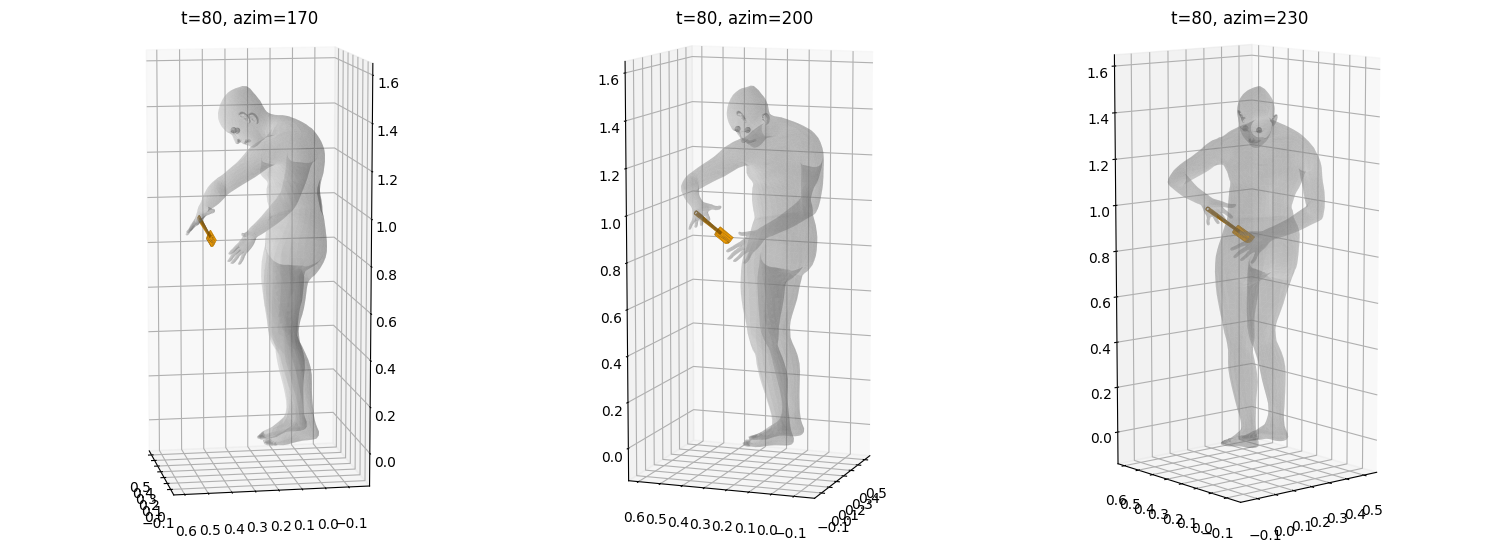

In [41]:
def render_frame(t, azims=(170, 200, 230)):
    with torch.no_grad():
        out = m(global_orient  =torch.from_numpy(fitted_go[t:t+1]),
                body_pose      =torch.from_numpy(fitted_bp[t:t+1]),
                left_hand_pose =torch.from_numpy(fitted_lh[t:t+1]),   # fitted finger curl
                right_hand_pose=torch.from_numpy(fitted_rh[t:t+1]),
                transl         =torch.from_numpy(fitted_tr[t:t+1]),
                betas          =betas_fit)
    Vb, Fb = out.vertices[0].numpy(), m.faces
    R_t = Rot.from_rotvec(obj_angles[t]).as_matrix()
    Vo = spatula_obj.vertices @ R_t.T + obj_trans[t]
    Fo = spatula_obj.faces
    pts = np.vstack([Vb, Vo]); lo, hi = pts.min(0) - 0.1, pts.max(0) + 0.1

    fig = plt.figure(figsize=(5 * len(azims), 6))
    for i, az in enumerate(azims):
        ax = fig.add_subplot(1, len(azims), i + 1, projection='3d')
        ax.plot_trisurf(Vb[:,0], Vb[:,2], Vb[:,1], triangles=Fb,
                        color='lightgray', alpha=0.3, linewidth=0)
        ax.plot_trisurf(Vo[:,0], Vo[:,2], Vo[:,1], triangles=Fo,
                        color='orange', alpha=0.95, linewidth=0)
        ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
        ax.set_box_aspect(((hi-lo)[0], (hi-lo)[2], (hi-lo)[1]))
        ax.view_init(elev=10, azim=az); ax.set_title(f't={t}, azim={az}')
    plt.tight_layout(); plt.show()

render_frame(80)

## Render video by running `visualization/visualize.py`

Runs InterAct's official visualization **script** as a subprocess — identical to
`python visualization/visualize.py humoto` from the terminal. This reuses the exact
CLI code path (not a re-implementation), so the output matches what you'd get on the
command line.

Requires the edits already in `visualize.py`: the `HUMOTO` dispatch branch, the
commented-out SMPL-H blocks, and `sys.path.append('./text2interaction')`.

Output → `./results/HUMOTO_<seq>_<obj>.mp4` (one per sequence in `data/humoto/sequences_canonical/`).

In [47]:
import subprocess, sys, glob, os

# Same as: python visualization/visualize.py humoto
proc = subprocess.run(
    [sys.executable, 'visualization/visualize.py', 'humoto'],
    capture_output=True, text=True,
)
print('return code:', proc.returncode)
print('--- stdout (tail) ---')
print(proc.stdout[-2000:])
if proc.returncode != 0:
    print('--- stderr (tail) ---')
    print(proc.stderr[-3000:])

# List the resulting videos
for mp4 in sorted(glob.glob('./results/HUMOTO_*.mp4')):
    print('video:', mp4, f'({os.path.getsize(mp4)//1024} KB)')

return code: 0
--- stdout (tail) ---
baking_with_spatula_mixing_bowl_and_scooping_to_tray-244

video: ./results/HUMOTO_baking_with_spatula_mixing_bowl_and_scooping_to_tray-244_spatula.mp4 (153 KB)


## Play Ground 
Checking if the demo run the same as the process humotot.py 

In [ ]:
import numpy as np, os, filecmp

def compare_humoto_outputs(dir_a, dir_b):
    """Compare every output file under dir_a against its counterpart in dir_b."""
    def cmp_npz(pa, pb):
        a, b = np.load(pa, allow_pickle=True), np.load(pb, allow_pickle=True)
        if set(a.files) != set(b.files): return f'KEY MISMATCH'
        parts = []
        for k in a.files:
            va, vb = a[k], b[k]
            if va.shape != vb.shape: parts.append(f'{k}:SHAPE'); continue
            if va.dtype.kind in 'fiub':
                parts.append(f'{k}:{np.abs(va.astype(float)-vb.astype(float)).max():.2e}')
            else:
                parts.append(f'{k}:{"eq" if (va==vb).all() else "DIFF"}')
        return '  '.join(parts)

    ok = True
    for root, _, files in os.walk(dir_a):
        for f in files:
            pa = os.path.join(root, f); pb = pa.replace(dir_a, dir_b, 1)
            rel = os.path.relpath(pa, dir_a)
            if not os.path.exists(pb):
                print(f'[MISSING] {rel}'); ok = False; continue
            if f.endswith('.npz'):   print(f'{rel}: {cmp_npz(pa, pb)}')
            elif f.endswith('.npy'): print(f'{rel}: maxdiff={np.abs(np.load(pa)-np.load(pb)).max():.2e}')
            elif f.endswith('.obj'): print(f'{rel}: {"identical" if filecmp.cmp(pa, pb, shallow=False) else "DIFFERENT"}')
    return ok

compare_humoto_outputs('data/humoto_temp', 'data/humoto')


Test trimesh.sample.sample_surface vs naive approach 

area-weighted (ours)      max gap=  0.9cm ( 3.3% of 26cm diag)  mean gap=0.3cm  unique pts=340
naive vertex              max gap=  3.3cm (12.8% of 26cm diag)  mean gap=0.9cm  unique pts=243


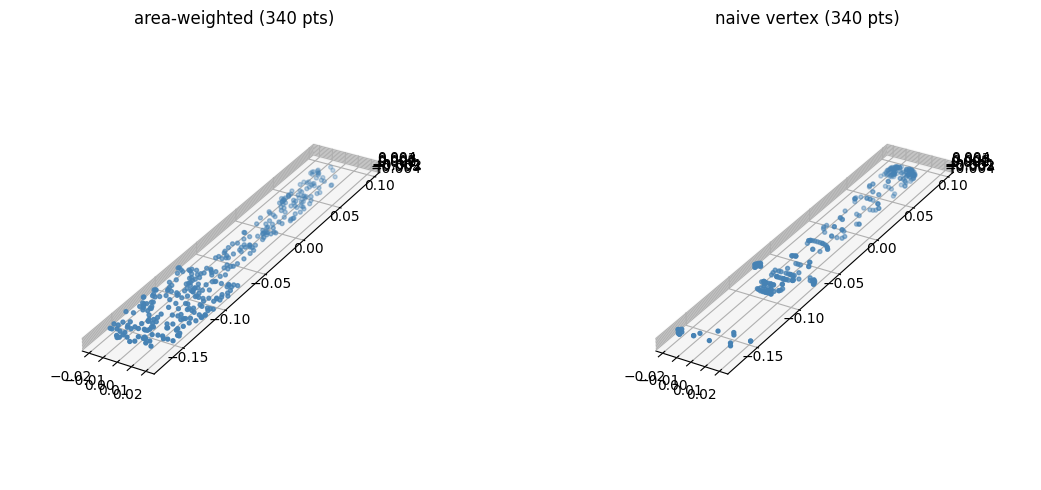

In [ ]:
import trimesh, numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

obj_dir = "./data/humoto/objects/spatula"

mesh = trimesh.load(f'{obj_dir}/spatula.obj')

# Method A: our area-weighted surface sampling
np.random.seed(0)
pts_area, _ = trimesh.sample.sample_surface(mesh, 340)

# Method B: naive random vertex subsample (what could clump)
np.random.seed(0)
vidx = np.random.choice(len(mesh.vertices), 340, replace=True)
pts_vert = mesh.vertices[vidx]

# Coverage metric: sample a DENSE reference set, measure distance from each
# reference point to the nearest of the 340. The MAX = largest uncovered gap.
ref, _ = trimesh.sample.sample_surface(mesh, 5000)
diag = np.linalg.norm(mesh.bounds[1] - mesh.bounds[0])   # object diagonal for scale

for name, pts in [('area-weighted (ours)', pts_area), ('naive vertex', pts_vert)]:
    tree = cKDTree(pts)
    gaps, _ = tree.query(ref)                 # nearest-sample distance for each ref point
    print(f"{name:24s}  max gap={gaps.max()*100:5.1f}cm "
          f"({gaps.max()/diag*100:4.1f}% of {diag*100:.0f}cm diag)  "
          f"mean gap={gaps.mean()*100:.1f}cm  unique pts={len(np.unique(pts,axis=0))}")

# Visualize both
fig = plt.figure(figsize=(12, 5))
for i, (name, pts) in enumerate([('area-weighted', pts_area), ('naive vertex', pts_vert)]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=8, c='steelblue')
    ax.set_title(f"{name} (340 pts)")
    ax.set_box_aspect((mesh.bounds[1]-mesh.bounds[0]))
plt.tight_layout(); plt.show()


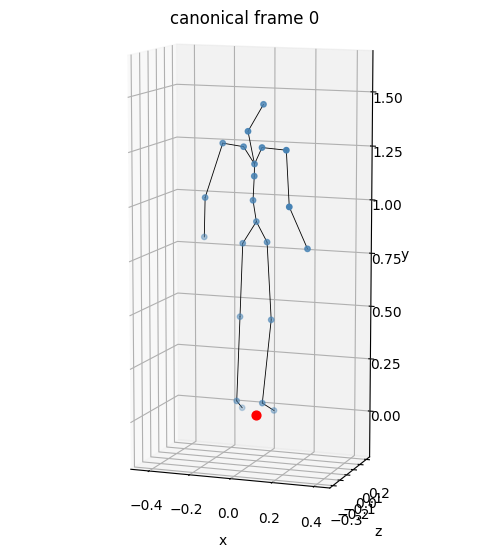

In [45]:
import numpy as np, torch, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
SEQ = 'baking_with_spatula_mixing_bowl_and_scooping_to_tray-244'
h = np.load(f'data/humoto/sequences_canonical/{SEQ}/human.npz', allow_pickle=True)
p, b, t = h['poses'], h['betas'], h['trans']
with torch.no_grad():
    J = m(global_orient=torch.from_numpy(p[0:1,:3]).float(),
          body_pose=torch.from_numpy(p[0:1,3:66]).float(),
          transl=torch.from_numpy(t[0:1]).float(),
          betas=torch.from_numpy(b[None]).float()).joints[0,:22].numpy()
    
lo, hi = J.min(0) - 0.2, J.max(0) + 0.2
PARENTS=[-1,0,0,0,1,2,3,4,5,6,7,8,9,9,9,12,13,14,16,17,18,19]
fig=plt.figure(figsize=(5,7)); ax=fig.add_subplot(111,projection='3d')
for k,pa in enumerate(PARENTS):
    if pa>=0: ax.plot([J[pa,0],J[k,0]],[J[pa,2],J[k,2]],[J[pa,1],J[k,1]],'k-',lw=0.6)
ax.scatter(J[:,0],J[:,2],J[:,1],c='steelblue',s=15)
ax.scatter([0],[0],[0],c='red',s=40)   # world origin (canonical center)
ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
ax.set_box_aspect((hi-lo)[[0, 2, 1]]); ax.view_init(elev=10, azim=-70)
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y'); ax.set_title('canonical frame 0')
plt.tight_layout(); plt.show()


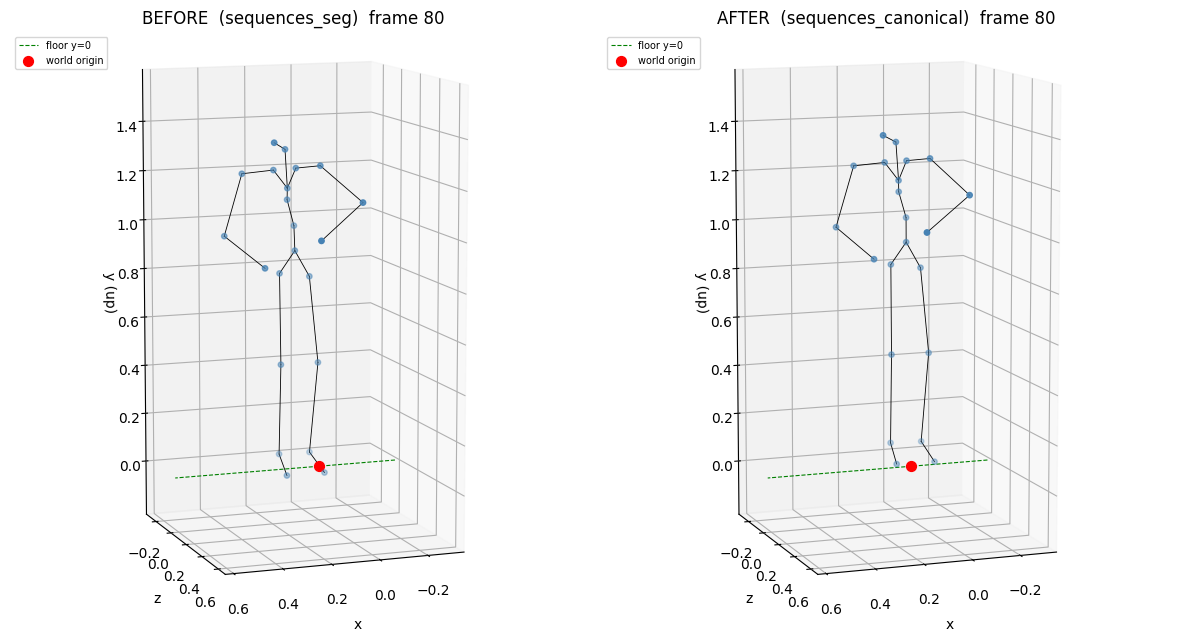

In [44]:
import numpy as np, torch, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SEQ = 'baking_with_spatula_mixing_bowl_and_scooping_to_tray-244'
before = np.load(f'data/humoto/sequences_seg/{SEQ}/human.npz',        allow_pickle=True)
after  = np.load(f'data/humoto/sequences_canonical/{SEQ}/human.npz',  allow_pickle=True)
PARENTS_ = [-1,0,0,0,1,2,3,4,5,6,7,8,9,9,9,12,13,14,16,17,18,19]

def _joints(hnpz, t):
    p, b, tr = hnpz['poses'], hnpz['betas'], hnpz['trans']
    with torch.no_grad():
        return m(global_orient=torch.from_numpy(p[t:t+1, :3]).float(),
                 body_pose   =torch.from_numpy(p[t:t+1, 3:66]).float(),
                 transl      =torch.from_numpy(tr[t:t+1]).float(),
                 betas       =torch.from_numpy(b[None]).float()).joints[0, :22].numpy()

def compare_before_after(t=0):
    Jb, Ja = _joints(before, t), _joints(after, t)
    both = np.vstack([Jb, Ja])
    lo, hi = both.min(0) - 0.2, both.max(0) + 0.2
    lo[1] = min(lo[1], 0.0)                      # make sure y=0 (floor) is in view
    fig = plt.figure(figsize=(12, 6))
    for i, (J, title) in enumerate([(Jb, 'BEFORE  (sequences_seg)'),
                                    (Ja, 'AFTER  (sequences_canonical)')]):
        ax = fig.add_subplot(1, 2, i+1, projection='3d')
        for k, pa in enumerate(PARENTS_):
            if pa >= 0:
                ax.plot([J[pa,0],J[k,0]],[J[pa,2],J[k,2]],[J[pa,1],J[k,1]], 'k-', lw=0.6)
        ax.scatter(J[:,0], J[:,2], J[:,1], c='steelblue', s=15)
        ax.scatter([0],[0],[0], c='red', s=50, label='world origin')          # centering check
        ax.plot([lo[0],hi[0]], [0,0], [0,0], 'g--', lw=0.8, label='floor y=0')  # floor check
        ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[2], hi[2]); ax.set_zlim(lo[1], hi[1])
        ax.set_box_aspect((hi[0]-lo[0], hi[2]-lo[2], hi[1]-lo[1]))
        ax.view_init(elev=10, azim=70)
        ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y (up)')
        ax.set_title(f'{title}  frame {t}'); ax.legend(loc='upper left', fontsize=7)
    plt.tight_layout(); plt.show()

compare_before_after(80)
